<a href="https://colab.research.google.com/github/cynthianekesa/Misala-App/blob/main/Droneplantenv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Drone Medicinal Plant Identifier - Reinforcement Learning**

This notebook simulates a drone navigating a 2D grid forest. At each cell, the drone can choose to move or use a TensorFlow model to identify a medicinal plant. Rewards are given for correct identifications.

In [ ]:
!pip install stable-baselines3[extra] --quiet
!pip install gymnasium[all] --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.2/187.2 kB 12.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [33]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from matplotlib import patches
from PIL import Image
import tensorflow as tf

class DronePlantEnv(gym.Env):
    def __init__(self,
                 plant_folder='/content/drive/MyDrive/plants',
                 model_path='/content/drive/MyDrive/model1.h5',
                 grid_size=10,
                 render_mode='vector'):  # 'vector' or 'image'

        super(DronePlantEnv, self).__init__()
        self.grid_size = (grid_size, grid_size)
        self.plant_folder = plant_folder
        self.render_mode = render_mode

        # Setup GPU for TensorFlow
        gpus = tf.config.list_physical_devices('GPU')
        if gpus:
            try:
                for gpu in gpus:
                    tf.config.experimental.set_memory_growth(gpu, True)
            except RuntimeError as e:
                print(e)

        # Load the model on GPU
        with tf.device('/GPU:0'):
            self.model = tf.keras.models.load_model(model_path)
        self.class_names = sorted(os.listdir(plant_folder))

        # Observation space
        if self.render_mode == 'image':
            # Increased observation space shape for larger image
            self.observation_space = spaces.Box(
                low=0.0, high=1.0, shape=(256, 256, 3), dtype=np.float32)
        else:
            self.observation_space = spaces.Box(
                low=0.0,
                high=1.0,
                shape=(2 + grid_size * grid_size,),
                dtype=np.float32
            )

        self.action_space = spaces.Discrete(5)  # up, down, left, right, identify
        self.initial_plant_positions = self._generate_plant_positions()
        self.plant_images = self._load_plant_images()
        self.max_steps = 200
        self.current_step = 0
        self.reset()

    def _generate_plant_positions(self):
        random.seed(42)
        positions = set()
        while len(positions) < 27:
            positions.add((random.randint(0, self.grid_size[0] - 1),
                           random.randint(0, self.grid_size[1] - 1)))
        return dict(zip(self.class_names, list(positions)))

    def _load_plant_images(self):
        images = {}
        for cls in self.class_names:
            folder = os.path.join(self.plant_folder, cls)
            image_files = [f for f in os.listdir(folder) if f.endswith(('jpg', 'png'))]
            if image_files:
                img_path = os.path.join(folder, image_files[0])
                images[cls] = Image.open(img_path).resize((40, 40))
        return images

    def reset(self, seed=None, options=None):
        self.drone_pos = [0, 0]
        self.visited = set()
        self.last_prediction = None
        self.current_step = 0
        self.plant_positions = self.initial_plant_positions.copy()
        return self._get_obs(), {}

    def step(self, action):
        x, y = self.drone_pos
        reward = 0
        done = False

        # Store previous position for visited
        prev_pos = tuple(self.drone_pos)

        # Move
        if action == 0 and y > 0: y -= 1  # Up
        elif action == 1 and y < self.grid_size[1] - 1: y += 1  # Down
        elif action == 2 and x > 0: x -= 1  # Left
        elif action == 3 and x < self.grid_size[0] - 1: x += 1  # Right
        elif action == 4:  # Identify
            self.last_prediction = self._identify_plant(x, y)
            if self.last_prediction:
                pred_cls, confidence = self.last_prediction
                actual_cls = None
                plant_key_to_remove = None
                for cls, pos in self.plant_positions.items():
                    if list(pos) == [x, y]:
                        actual_cls = cls
                        plant_key_to_remove = cls
                        break
                if actual_cls:
                    if pred_cls == actual_cls:
                        reward += 50 + (confidence * 40)
                        if plant_key_to_remove:
                            del self.plant_positions[plant_key_to_remove]
                            reward += 20
                    else:
                        reward -= 5
                else:
                    reward -= 1
        else:
            self.last_prediction = None # Clear prediction if not identifying

        self.drone_pos = [x, y]
        new_pos = tuple(self.drone_pos)

        # Exploration reward
        if new_pos not in self.visited and new_pos != prev_pos:
            reward += 1
            self.visited.add(new_pos)
        else:
            reward -= 0.7

        self.current_step += 1
        reward -= 0.01  # step penalty

        if self.current_step >= self.max_steps or not self.plant_positions:
            done = True
            if not self.plant_positions:
                reward += 100
                reward += (self.max_steps - self.current_step) * 0.5

        return self._get_obs(), reward, done, False, {}


    def _identify_plant(self, x, y):
        for cls, pos in self.plant_positions.items():
            if list(pos) == [x, y]:
                image = self.plant_images[cls].convert("RGB")
                arr = np.array(image.resize((224, 224))) / 255.0
                with tf.device('/GPU:0'):
                    pred = self.model.predict(np.expand_dims(arr, axis=0), verbose=0)[0]
                idx = np.argmax(pred)
                return (self.class_names[idx], float(pred[idx]))
        return ("None", 0.0)

    def _get_obs(self):
        if self.render_mode == 'image':
            return self._rendered_image_obs()
        else:
            grid = np.zeros(self.grid_size, dtype=np.float32)
            for cls, (px, py) in self.plant_positions.items():
                grid[px, py] = 1.0
            flat_grid = grid.flatten()
            obs = np.array([self.drone_pos[0], self.drone_pos[1]], dtype=np.float32)
            return np.concatenate([obs, flat_grid])

    def _rendered_image_obs(self):
        fig, ax = plt.subplots(figsize=(8, 8), dpi=96)
        ax.set_xlim(0, self.grid_size[0])
        ax.set_ylim(0, self.grid_size[1])
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis("off")

        for (x, y) in self.visited:
            rect = patches.Rectangle((x, self.grid_size[1] - 1 - y), 1, 1,
                                     linewidth=1, edgecolor='none', facecolor='lightgreen', alpha=0.4)
            ax.add_patch(rect)

        for cls, (px, py) in self.plant_positions.items():
            img = self.plant_images[cls].convert("RGB")
            ax.imshow(img, extent=[px, px + 1, self.grid_size[1] - 1 - py, self.grid_size[1] - py])

        dx, dy = self.drone_pos
        drone_center_x = dx + 0.5
        drone_center_y = self.grid_size[1] - 1 - dy + 0.5

        drone_body = patches.Rectangle((drone_center_x - 0.3, drone_center_y - 0.1),
                                       0.6, 0.2, color='gray')
        ax.add_patch(drone_body)

        arm_length = 0.4
        arm_width = 0.05
        ax.add_patch(patches.Rectangle((drone_center_x - arm_length / 2, drone_center_y + 0.1),
                                       arm_length, arm_width, color='black'))
        ax.add_patch(patches.Rectangle((drone_center_x - arm_length / 2, drone_center_y - 0.1 - arm_width),
                                       arm_length, arm_width, color='black'))
        ax.add_patch(patches.Rectangle((drone_center_x - 0.3 - arm_width, drone_center_y - arm_length / 2),
                                       arm_width, arm_length, color='black'))
        ax.add_patch(patches.Rectangle((drone_center_x + 0.3, drone_center_y - arm_length / 2),
                                       arm_width, arm_length, color='black'))

        if self.last_prediction:
            cls, conf = self.last_prediction
            ax.text(0.5, self.grid_size[1] + 0.5, f"Prediction: {cls} ({conf:.2f})",
                    fontsize=12, ha='center', va='bottom', transform=ax.transData)
        elif not self.plant_positions:
            ax.text(0.5, self.grid_size[1] + 0.5, "All plants identified!",
                    fontsize=12, ha='center', va='bottom', transform=ax.transData)
        else:
            ax.text(0.5, self.grid_size[1] + 0.5, "Explore and Identify!",
                    fontsize=12, ha='center', va='bottom', transform=ax.transData)


        fig.canvas.draw()
        image_rgba = np.asarray(fig.canvas.buffer_rgba())
        image_rgb = image_rgba[:, :, :3]
        plt.close(fig)

        # Convert to uint8 and return
        if image_rgb.size == 0:
            return np.zeros((int(self.grid_size[0]*96/8), int(self.grid_size[1]*96/8), 3), dtype=np.uint8) # Return a black image of a reasonable size
        else:
            return image_rgb.astype(np.uint8) # Return as uint8 without resizing


    def render(self):
        if self.render_mode == 'image':
            return self._rendered_image_obs() # Return the rendered image when in 'image' mode
        else:
            fig, ax = plt.subplots(figsize=(6, 6))
            ax.set_xlim(0, self.grid_size[0])
            ax.set_ylim(0, self.grid_size[1])
            ax.set_xticks(np.arange(self.grid_size[0] + 1))
            ax.set_yticks(np.arange(self.grid_size[1] + 1))
            ax.grid(True)

            for (x, y) in self.visited:
                rect = patches.Rectangle((x, self.grid_size[1] - 1 - y), 1, 1,
                                         linewidth=1, edgecolor='none', facecolor='lightgreen', alpha=0.4)
                ax.add_patch(rect)

            for cls, (px, py) in self.plant_positions.items():
                img = self.plant_images[cls].convert("RGB")
                ax.imshow(img, extent=[px, px + 1, self.grid_size[1] - 1 - py, self.grid_size[1] - py])

            dx, dy = self.drone_pos
            drone_center_x = dx + 0.5
            drone_center_y = self.grid_size[1] - 1 - dy + 0.5

            drone_body = patches.Rectangle((drone_center_x - 0.3, drone_center_y - 0.1),
                                           0.6, 0.2, color='gray')
            ax.add_patch(drone_body)

            arm_length = 0.4
            arm_width = 0.05
            ax.add_patch(patches.Rectangle((drone_center_x - arm_length / 2, drone_center_y + 0.1),
                                           arm_length, arm_width, color='black'))
            ax.add_patch(patches.Rectangle((drone_center_x - arm_length / 2, drone_center_y - 0.1 - arm_width),
                                           arm_length, arm_width, color='black'))
            ax.add_patch(patches.Rectangle((drone_center_x - 0.3 - arm_width, drone_center_y - arm_length / 2),
                                           arm_width, arm_length, color='black'))
            ax.add_patch(patches.Rectangle((drone_center_x + 0.3, drone_center_y - arm_length / 2),
                                           arm_width, arm_length, color='black'))

            if self.last_prediction:
                cls, conf = self.last_prediction
                ax.set_title(f"Prediction: {cls} ({conf:.2f})", fontsize=12)
            elif not self.plant_positions:
                ax.set_title("All plants identified!", fontsize=12)
            else:
                ax.set_title("Explore and Identify!", fontsize=12)

            plt.show()

In [34]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.vec_env import DummyVecEnv
import tensorflow as tf

def make_env():
    return DronePlantEnv(render_mode='vector')  # Use vector mode for speed

env = DummyVecEnv([make_env])

In [35]:
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold

ppo_model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=2.5e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.995,
    gae_lambda=0.95,
    ent_coef=0.02,
    clip_range=0.2,
    vf_coef=0.5,
    max_grad_norm=0.5,
    policy_kwargs=dict(
        net_arch=dict(pi=[128, 128], vf=[128, 128])
    ),
    tensorboard_log="./ppo_plant_tensorboard/"
)

Using cpu device


In [36]:
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold
from stable_baselines3.common.monitor import Monitor

eval_env = Monitor(make_env()) # Wrap the evaluation environment with Monitor
eval_callback = EvalCallback(
    DummyVecEnv([lambda: eval_env]),
    best_model_save_path='./logs/',
    log_path='./logs/',
    eval_freq=5000,
    deterministic=True,
    render=False
)

ppo_model.learn(total_timesteps=800_000, callback=eval_callback)

Streaming output truncated to the last 5000 lines.
| eval/                   |             |
|    mean_ep_length       | 200         |
|    mean_reward          | 119         |
| time/                   |             |
|    total_timesteps      | 330000      |
| train/                  |             |
|    approx_kl            | 0.008047303 |
|    clip_fraction        | 0.0839      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.67       |
|    explained_variance   | 0.99        |
|    learning_rate        | 0.00025     |
|    loss                 | 67.4        |
|    n_updates            | 1610        |
|    policy_gradient_loss | -0.000917   |
|    value_loss           | 125         |
-----------------------------------------
-------------------------------
| time/              |        |
|    fps             | 84     |
|    iterations      | 162    |
|    time_elapsed    | 3908   |
|    total_timesteps | 331776 |
-------------------------------
-----------

In [37]:
ppo_model.save("ppo_plant_drone")

In [38]:
env = DronePlantEnv(render_mode='vector') # Changed render_mode to 'vector'
obs, _ = env.reset()
done = False
total_reward = 0

while not done:
    action, _ = ppo_model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = env.step(action)
    total_reward += reward


print("Total reward:", total_reward)

Total reward: 549.1630644798227


In [39]:
import imageio

frames = []
# Ensure the environment is initialized with render_mode='image' for frame generation
env = DronePlantEnv(render_mode='image')
obs, _ = env.reset()
done = False

for _ in range(200):
    frame = env.render()
    frames.append(frame)

    # Switch to vector mode for model prediction
    env.render_mode = 'vector'
    obs = env._get_obs() # Get observation in vector mode
    action, _ = ppo_model.predict(obs, deterministic=True)

    # Switch back to image mode for rendering the next frame
    env.render_mode = 'image'
    obs, reward, done, _, _ = env.step(action)


    if done:
        break

# Save as animated GIF with proper duration
imageio.mimsave('ppo_drone_run.gif', frames, duration=250)

In [40]:
# Load the best model
best_model_path = '/content/logs/best_model.zip'

env = DronePlantEnv(render_mode='vector')
ppo_model = PPO.load(best_model_path, env=env)


obs, _ = env.reset()
done = False
total_reward = 0

while not done:
    action, _ = ppo_model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = env.step(action)
    total_reward += reward


print("Total reward for the best model:", total_reward)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Total reward for the best model: 589.9630644798237


In [46]:
import imageio
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

frames = []

env = DronePlantEnv(render_mode='image')

best_model_path = './logs/best_model.zip'


# Create a dummy environment for loading the model
dummy_env_vector = DummyVecEnv([lambda: DronePlantEnv(render_mode='vector')])
ppo_model = PPO.load(best_model_path, env=dummy_env_vector)


obs, _ = env.reset()
done = False

# Run an episode to capture frames
for _ in range(env.max_steps): # Limit the number of steps for the GIF
    # The model expects vector observations, so get the observation in vector mode
    env.render_mode = 'vector'
    obs_vector = env._get_obs()

    # Predict action using the model
    action, _ = ppo_model.predict(obs_vector, deterministic=True)

    # Switch back to image mode for rendering and stepping
    env.render_mode = 'image'
    obs, reward, done, _, _ = env.step(action)

    # Get rendered frame
    frame = env.render()
    frames.append(frame)

    if done:
        break

# Save as animated GIF with proper duration
imageio.mimsave('ppo_drone_best_model_run.gif', frames, duration=150)

print("GIF saved as ppo_drone_best_model_run.gif")

GIF saved as ppo_drone_best_model_run.gif


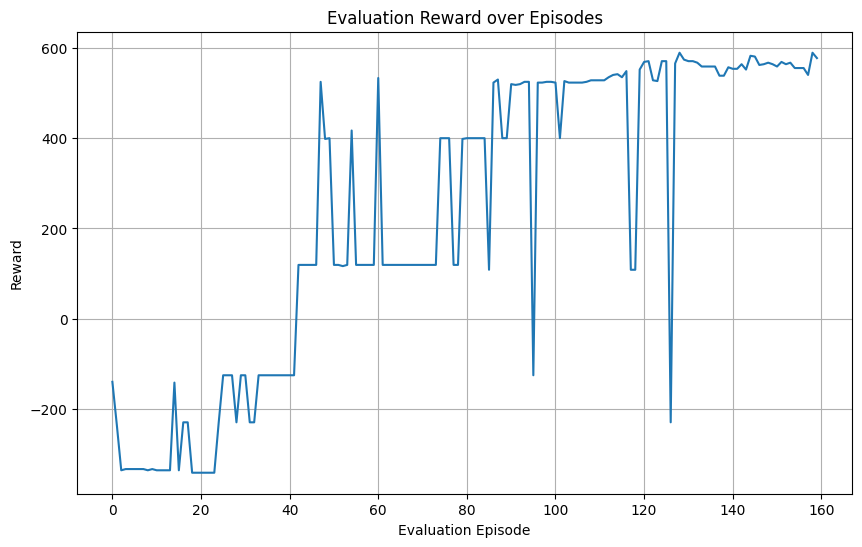

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Load the evaluation results from the .npz file
log_dir = "./logs/"
eval_file = os.path.join(log_dir, "evaluations.npz")

if os.path.exists(eval_file):
    data = np.load(eval_file)
    # The rewards are stored in the 'results' key
    rewards = data['results'][:, 0] # Assuming the first column is the reward

    # Plot the reward
    plt.figure(figsize=(10, 6))
    plt.plot(rewards)
    plt.xlabel('Evaluation Episode')
    plt.ylabel('Reward')
    plt.title('Evaluation Reward over Episodes')
    plt.grid(True)
    plt.show()
else:
    print("Evaluation file not found:", eval_file)